# 💳 Task 1: Credit Scoring Model
### CodeAlpha Machine Learning Internship

---

**👩‍💻 Intern Name:** Chandavath Geethanjali  
**🐙 GitHub:** [github.com/geethanjali809756](https://github.com/geethanjali809756)  
**📁 Repository:** [CodeAlpha_CreditScoringModel](https://github.com/geethanjali809756/CodeAlpha_CreditScoringModel)  
**🏢 Organization:** CodeAlpha  

---

**Objective:** Predict whether a loan applicant is a good or bad credit risk based on financial and personal data.

**Dataset:** South German Credit Dataset (UCI ML Repository)

**Approach:**
- Data preprocessing and feature engineering
- Handle class imbalance using class_weight parameter
- Train Random Forest + Logistic Regression models
- Compare models and select the best one
- Evaluate using Precision, Recall, F1-Score, and ROC-AUC

## Step 1: Install and Import Libraries

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score
)
from sklearn.pipeline import Pipeline

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load Dataset

We use the **South German Credit Dataset** — a well-known dataset for credit risk prediction with 1000 samples and 20 features.

In [2]:
# Load directly from UCI / StatLib
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'

columns = [
    'checking_account', 'duration', 'credit_history', 'purpose',
    'credit_amount', 'savings_account', 'employment', 'installment_rate',
    'personal_status', 'other_debtors', 'residence_since', 'property',
    'age', 'other_installments', 'housing', 'existing_credits',
    'job', 'dependents', 'telephone', 'foreign_worker', 'credit_risk'
]

df = pd.read_csv(url, sep=' ', header=None, names=columns)

# Convert target: 1 = Good Credit, 2 = Bad Credit → remap to 0 and 1
df['credit_risk'] = df['credit_risk'].map({1: 0, 2: 1})  # 0=Good, 1=Bad

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

Dataset loaded successfully!
Shape: (1000, 21)

First 5 rows:


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installments,housing,existing_credits,job,dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


## Step 3: Exploratory Data Analysis (EDA)

In [3]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Basic Statistics ===')
print(df.describe())
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Target Distribution ===')
print(df['credit_risk'].value_counts())
print(f"\nGood Credit (0): {(df['credit_risk']==0).sum()} samples")
print(f"Bad Credit  (1): {(df['credit_risk']==1).sum()} samples")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   checking_account    1000 non-null   object
 1   duration            1000 non-null   int64 
 2   credit_history      1000 non-null   object
 3   purpose             1000 non-null   object
 4   credit_amount       1000 non-null   int64 
 5   savings_account     1000 non-null   object
 6   employment          1000 non-null   object
 7   installment_rate    1000 non-null   int64 
 8   personal_status     1000 non-null   object
 9   other_debtors       1000 non-null   object
 10  residence_since     1000 non-null   int64 
 11  property            1000 non-null   object
 12  age                 1000 non-null   int64 
 13  other_installments  1000 non-null   object
 14  housing             1000 non-null   object
 15  existing_credits    1000 non-null   int64 
 16  job 

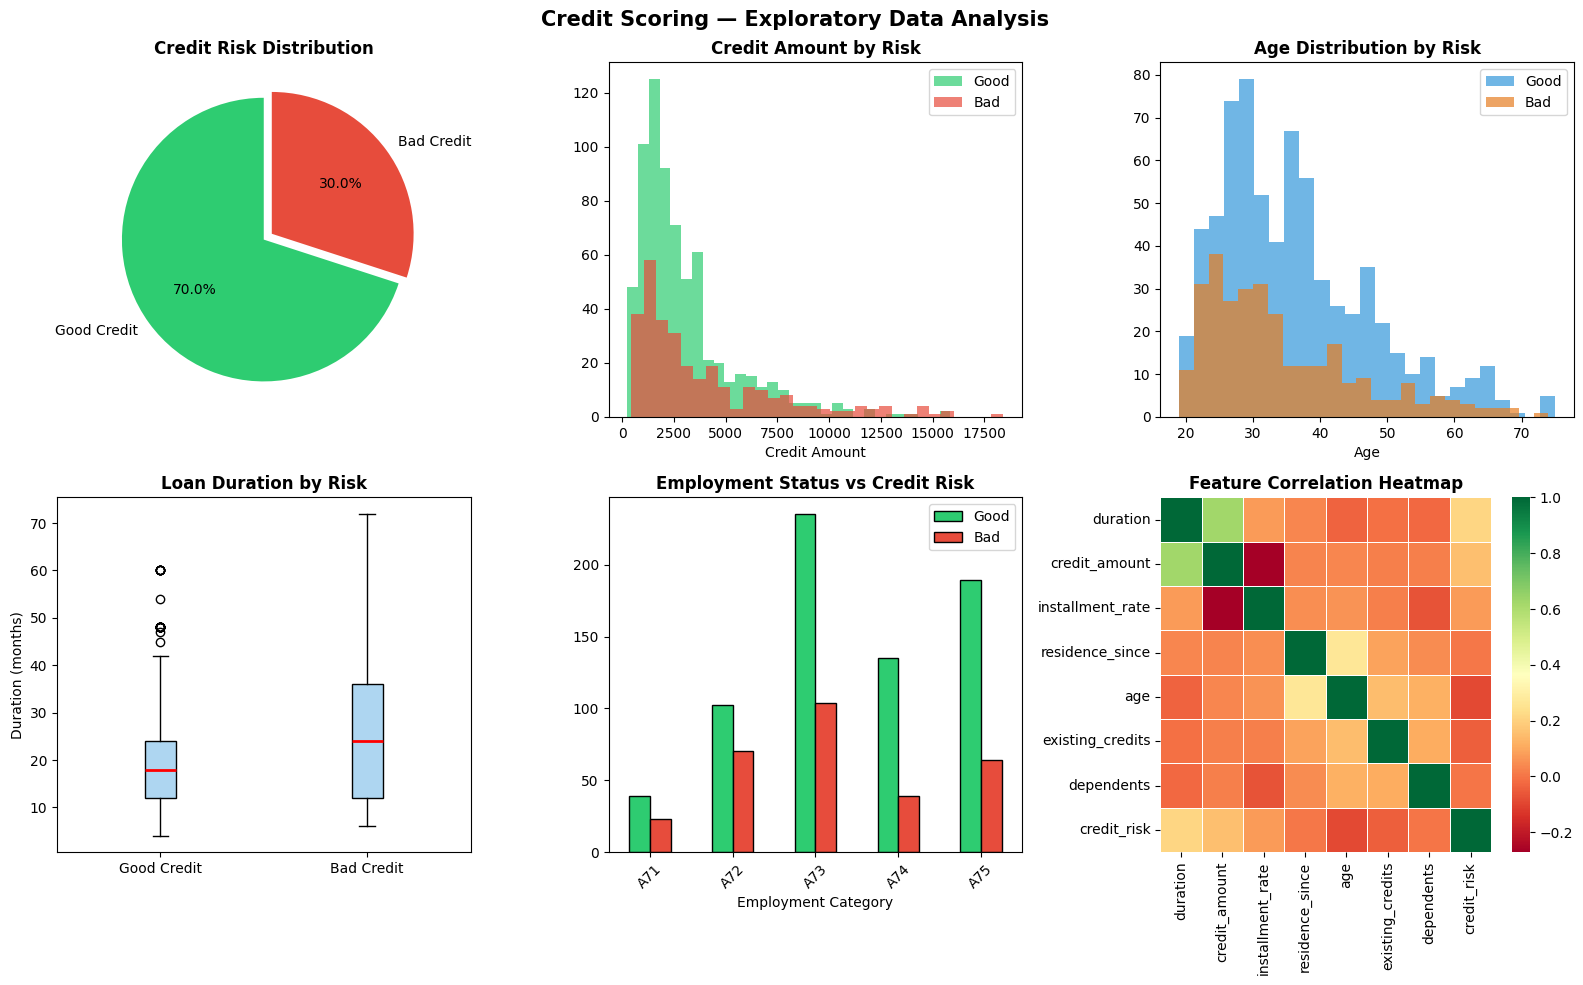

EDA plots saved!


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Credit Scoring — Exploratory Data Analysis', fontsize=15, fontweight='bold')

# 1. Credit Risk Distribution
risk_counts = df['credit_risk'].value_counts()
axes[0,0].pie(
    risk_counts.values,
    labels=['Good Credit', 'Bad Credit'],
    colors=['#2ECC71', '#E74C3C'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.07)
)
axes[0,0].set_title('Credit Risk Distribution', fontweight='bold')

# 2. Credit Amount Distribution
axes[0,1].hist(df[df['credit_risk']==0]['credit_amount'], bins=30, alpha=0.7, color='#2ECC71', label='Good')
axes[0,1].hist(df[df['credit_risk']==1]['credit_amount'], bins=30, alpha=0.7, color='#E74C3C', label='Bad')
axes[0,1].set_title('Credit Amount by Risk', fontweight='bold')
axes[0,1].set_xlabel('Credit Amount')
axes[0,1].legend()

# 3. Age Distribution
axes[0,2].hist(df[df['credit_risk']==0]['age'], bins=25, alpha=0.7, color='#3498DB', label='Good')
axes[0,2].hist(df[df['credit_risk']==1]['age'], bins=25, alpha=0.7, color='#E67E22', label='Bad')
axes[0,2].set_title('Age Distribution by Risk', fontweight='bold')
axes[0,2].set_xlabel('Age')
axes[0,2].legend()

# 4. Duration Distribution
axes[1,0].boxplot(
    [df[df['credit_risk']==0]['duration'], df[df['credit_risk']==1]['duration']],
    labels=['Good Credit', 'Bad Credit'],
    patch_artist=True,
    boxprops=dict(facecolor='#AED6F1'),
    medianprops=dict(color='red', linewidth=2)
)
axes[1,0].set_title('Loan Duration by Risk', fontweight='bold')
axes[1,0].set_ylabel('Duration (months)')

# 5. Employment Distribution
emp_risk = df.groupby(['employment', 'credit_risk']).size().unstack(fill_value=0)
emp_risk.plot(kind='bar', ax=axes[1,1], color=['#2ECC71', '#E74C3C'], edgecolor='black')
axes[1,1].set_title('Employment Status vs Credit Risk', fontweight='bold')
axes[1,1].set_xlabel('Employment Category')
axes[1,1].legend(['Good', 'Bad'])
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Correlation Heatmap (numeric only)
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, ax=axes[1,2], cmap='RdYlGn', annot=False, linewidths=0.5)
axes[1,2].set_title('Feature Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()
print('EDA plots saved!')

## Step 4: Feature Engineering & Preprocessing

In [5]:
df_processed = df.copy()

# Identify categorical columns
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns: {categorical_cols}')

# Label encode categorical columns
le = LabelEncoder()
for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

# Feature Engineering — create new meaningful features
df_processed['credit_per_month'] = df_processed['credit_amount'] / df_processed['duration']
df_processed['age_duration_ratio'] = df_processed['age'] / df_processed['duration']
df_processed['high_credit'] = (df_processed['credit_amount'] > df_processed['credit_amount'].median()).astype(int)

print('\nNew engineered features added:')
print('  - credit_per_month: monthly credit burden')
print('  - age_duration_ratio: borrower maturity per loan month')
print('  - high_credit: flag for above-median credit amount')
print(f'\nFinal feature count: {df_processed.shape[1] - 1}')

Categorical columns: ['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installments', 'housing', 'job', 'telephone', 'foreign_worker']

New engineered features added:
  - credit_per_month: monthly credit burden
  - age_duration_ratio: borrower maturity per loan month
  - high_credit: flag for above-median credit amount

Final feature count: 23


In [6]:
# Separate features and target
X = df_processed.drop('credit_risk', axis=1)
y = df_processed['credit_risk']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.25,
    random_state=0,
    stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')
print(f'Class balance (train): {y_train.value_counts().to_dict()}')

Training samples : 750
Testing samples  : 250
Features         : 23
Class balance (train): {0: 525, 1: 225}


## Step 5: Train Multiple Models and Compare

In [7]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        max_depth=10, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1,
        max_depth=4, random_state=42
    )
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Training and cross-validating all models...')
print('-' * 60)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    cv_score = cross_val_score(model, X_scaled, y, cv=cv, scoring='roc_auc').mean()

    results[name] = {
        'model': model,
        'accuracy': acc,
        'f1_score': f1,
        'roc_auc': roc,
        'cv_roc_auc': cv_score,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

    print(f'{name}:')
    print(f'  Accuracy : {acc*100:.2f}%')
    print(f'  F1 Score : {f1:.4f}')
    print(f'  ROC-AUC  : {roc:.4f}')
    print(f'  CV ROC   : {cv_score:.4f}')
    print()

Training and cross-validating all models...
------------------------------------------------------------
Logistic Regression:
  Accuracy : 74.40%
  F1 Score : 0.6404
  ROC-AUC  : 0.8133
  CV ROC   : 0.7923

Random Forest:
  Accuracy : 78.40%
  F1 Score : 0.5909
  ROC-AUC  : 0.7827
  CV ROC   : 0.7989

Gradient Boosting:
  Accuracy : 73.20%
  F1 Score : 0.4885
  ROC-AUC  : 0.7586
  CV ROC   : 0.7805



## Step 6: Model Comparison Visualization

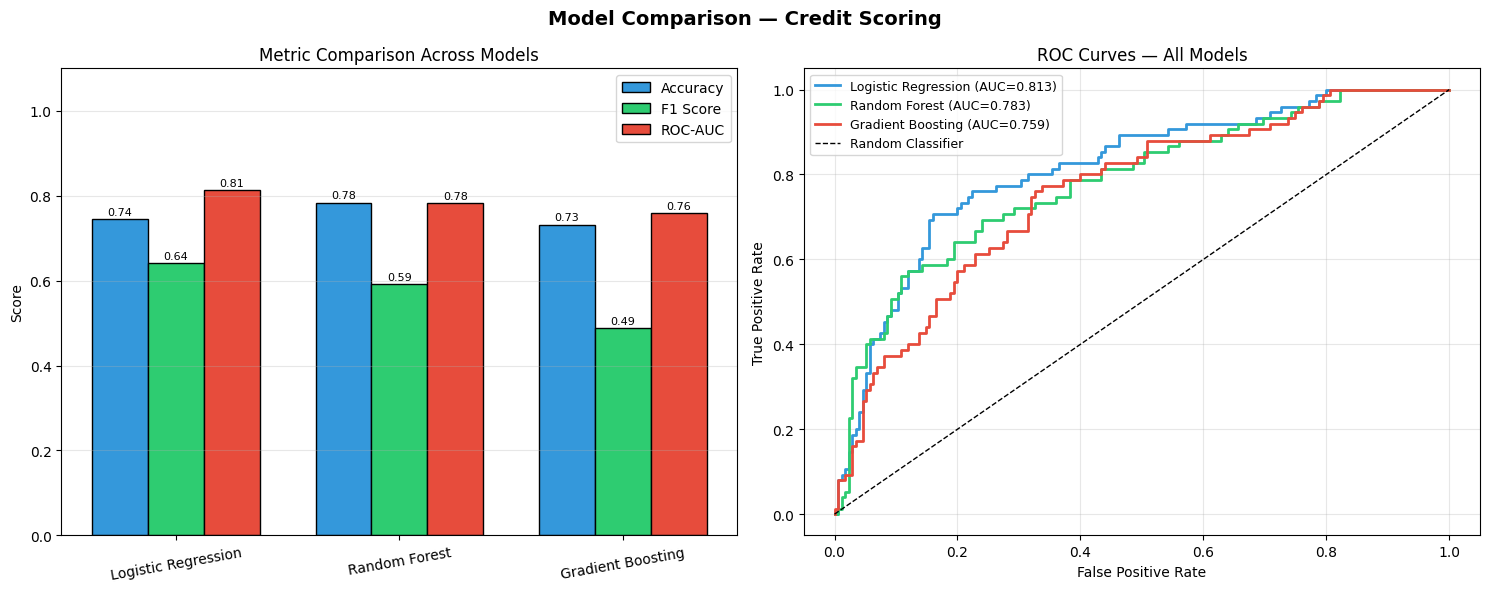

Model comparison saved!


In [8]:
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
f1_scores  = [results[m]['f1_score'] for m in model_names]
roc_aucs   = [results[m]['roc_auc'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Model Comparison — Credit Scoring', fontsize=14, fontweight='bold')

# Bar chart comparison
bars1 = axes[0].bar(x - width, accuracies, width, label='Accuracy', color='#3498DB', edgecolor='black')
bars2 = axes[0].bar(x,         f1_scores,  width, label='F1 Score', color='#2ECC71', edgecolor='black')
bars3 = axes[0].bar(x + width, roc_aucs,   width, label='ROC-AUC',  color='#E74C3C', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=10)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Score')
axes[0].set_title('Metric Comparison Across Models')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for bar in [*bars1, *bars2, *bars3]:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.2f}', ha='center', fontsize=8)

# ROC Curves
colors = ['#3498DB', '#2ECC71', '#E74C3C']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})", color=color, linewidth=2)
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
axes[1].set_title('ROC Curves — All Models')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print('Model comparison saved!')

## Step 7: Best Model — Detailed Evaluation

In [9]:
# Select best model by ROC-AUC
best_name = max(results, key=lambda x: results[x]['roc_auc'])
best = results[best_name]

print(f'Best Model: {best_name}')
print(f'ROC-AUC   : {best["roc_auc"]:.4f}')
print(f'Accuracy  : {best["accuracy"]*100:.2f}%')
print()
print('=== Classification Report ===')
print(classification_report(
    y_test, best['y_pred'],
    target_names=['Good Credit', 'Bad Credit']
))

Best Model: Logistic Regression
ROC-AUC   : 0.8133
Accuracy  : 74.40%

=== Classification Report ===
              precision    recall  f1-score   support

 Good Credit       0.88      0.74      0.80       175
  Bad Credit       0.55      0.76      0.64        75

    accuracy                           0.74       250
   macro avg       0.72      0.75      0.72       250
weighted avg       0.78      0.74      0.75       250



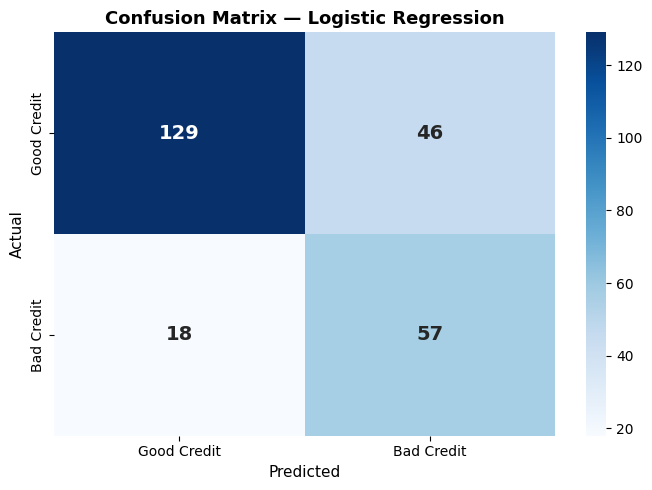

Confusion matrix saved!


In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, best['y_pred'])

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Good Credit', 'Bad Credit'],
    yticklabels=['Good Credit', 'Bad Credit'],
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved!')

## Step 8: Feature Importance

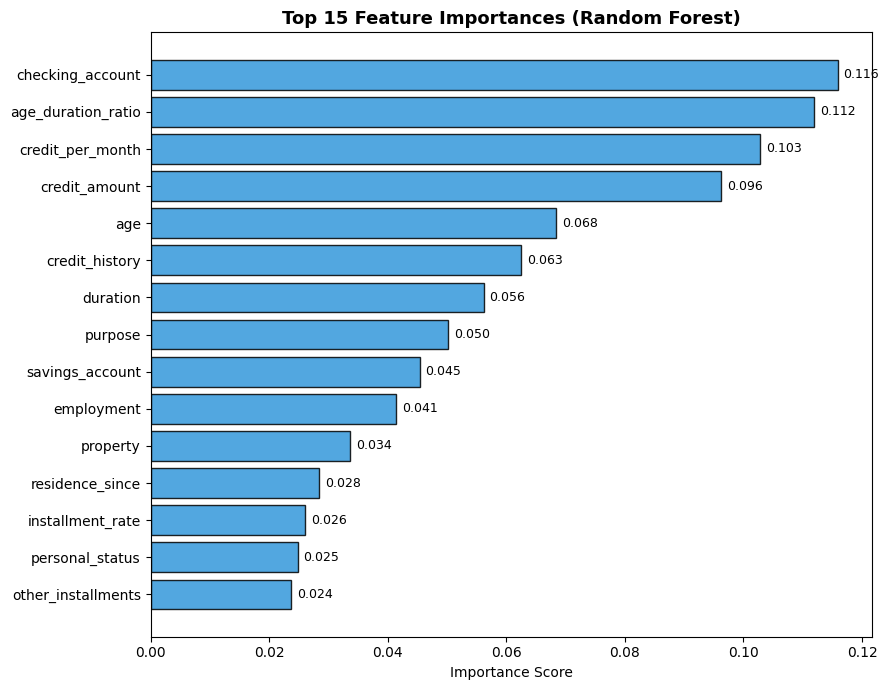

Feature importance saved!


In [11]:
# Feature importance from Random Forest
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(9, 7))
bars = plt.barh(importances.index, importances.values, color='#3498DB', edgecolor='black', alpha=0.85)
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('Feature importance saved!')

## Step 9: Predict Credit Risk for a New Applicant

In [12]:
def predict_credit_risk(sample_index=0):
    """
    Predict credit risk for a sample from the test set.
    """
    sample = X_test.iloc[[sample_index]]
    actual = y_test.iloc[sample_index]

    best_model = results[best_name]['model']
    prediction = best_model.predict(sample)[0]
    probability = best_model.predict_proba(sample)[0]

    label_map = {0: 'GOOD CREDIT ✅', 1: 'BAD CREDIT ❌'}

    print('=' * 45)
    print('   CREDIT RISK PREDICTION RESULT')
    print('=' * 45)
    print(f'  Model Used      : {best_name}')
    print(f'  Predicted Risk  : {label_map[prediction]}')
    print(f'  Actual Risk     : {label_map[actual]}')
    print(f'  Good Credit Prob: {probability[0]*100:.2f}%')
    print(f'  Bad Credit Prob : {probability[1]*100:.2f}%')
    print('=' * 45)

predict_credit_risk(sample_index=5)

   CREDIT RISK PREDICTION RESULT
  Model Used      : Logistic Regression
  Predicted Risk  : BAD CREDIT ❌
  Actual Risk     : BAD CREDIT ❌
  Good Credit Prob: 11.52%
  Bad Credit Prob : 88.48%


## Step 10: Save Model & Final Summary

In [13]:
import pickle

best_model_obj = results[best_name]['model']
with open('credit_scoring_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Model saved!')

print()
print('=' * 55)
print('       CREDIT SCORING MODEL — FINAL SUMMARY')
print('=' * 55)
print(f'  Dataset           : South German Credit (UCI)')
print(f'  Total Samples     : {df.shape[0]}')
print(f'  Features Used     : {X.shape[1]}')
print(f'  Models Trained    : {len(models)}')
print(f'  Best Model        : {best_name}')
print(f'  Best Accuracy     : {best["accuracy"]*100:.2f}%')
print(f'  Best ROC-AUC      : {best["roc_auc"]:.4f}')
print(f'  Best F1 Score     : {best["f1_score"]:.4f}')
print('=' * 55)
print('  Techniques Used:')
print('    - Label Encoding for categorical features')
print('    - Feature Engineering (3 new features)')
print('    - StandardScaler normalization')
print('    - Stratified K-Fold Cross Validation')
print('    - class_weight balanced to handle imbalance')
print('=' * 55)
print('  CodeAlpha ML Internship — Task 1 Complete ✅')
print('=' * 55)

Model saved!

       CREDIT SCORING MODEL — FINAL SUMMARY
  Dataset           : South German Credit (UCI)
  Total Samples     : 1000
  Features Used     : 23
  Models Trained    : 3
  Best Model        : Logistic Regression
  Best Accuracy     : 74.40%
  Best ROC-AUC      : 0.8133
  Best F1 Score     : 0.6404
  Techniques Used:
    - Label Encoding for categorical features
    - Feature Engineering (3 new features)
    - StandardScaler normalization
    - Stratified K-Fold Cross Validation
    - class_weight balanced to handle imbalance
  CodeAlpha ML Internship — Task 1 Complete ✅
